#Imports

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

# Load_Dataset

In [ ]:
df=pd.read_csv('/content/diabetes_data.csv')

# Data Understanding

In [ ]:
df.head()

,age,gender,bmi,bmi_category,systolic,diastolic,blood_pressure_category,cholesterol,cholesterol_category,glucose,diabetes_probability
0,55,Female,29.59,Overweight,112.0,89.5,Hypertension Stage 1,247,High,139,0.65
1,34,Male,30.68,Obesity,106.0,115.0,Hypertension Stage 2,255,High,101,0.60
2,26,Male,15.96,Underweight,96.0,97.0,Hypertension Stage 2,234,Borderline high,97,0.15
3,63,Male,15.61,Underweight,109.6,115.3,Hypertension Stage 2,261,High,143,0.70
4,37,Male,41.54,Obesity,110.0,103.0,Hypertension Stage 2,226,Borderline high,115,0.50


In [ ]:
df.tail()

,age,gender,bmi,bmi_category,systolic,diastolic,blood_pressure_category,cholesterol,cholesterol_category,glucose,diabetes_probability
9995,81,Male,18.44,Underweight,111.2,97.1,Hypertension Stage 2,247,High,137,0.70
9996,29,Male,37.29,Obesity,112.0,76.0,Normal,196,Normal,87,0.20
9997,84,Female,32.15,Obesity,114.8,92.4,Hypertension Stage 2,300,High,129,0.90
9998,76,Female,31.79,Obesity,117.2,125.6,Hypertension Stage 2,223,Borderline high,131,0.80
9999,18,Male,14.02,Underweight,97.0,92.0,Hypertension Stage 2,188,Normal,136,0.45


In [ ]:
print(df.shape)

(10000, 11)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      10000 non-null  int64  
 1   gender                   10000 non-null  object 
 2   bmi                      10000 non-null  float64
 3   bmi_category             10000 non-null  object 
 4   systolic                 10000 non-null  float64
 5   diastolic                10000 non-null  float64
 6   blood_pressure_category  10000 non-null  object 
 7   cholesterol              10000 non-null  int64  
 8   cholesterol_category     10000 non-null  object 
 9   glucose                  10000 non-null  int64  
 10  diabetes_probability     10000 non-null  float64
dtypes: float64(4), int64(3), object(4)
memory usage: 859.5+ KB


In [ ]:
df.describe()

,age,bmi,systolic,diastolic,cholesterol,glucose,diabetes_probability
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.062300,26.309132,106.052700,95.717600,228.748600,120.525300,0.489040
std,21.058294,8.396257,7.207495,17.863035,35.667787,21.095224,0.231504
min,18.000000,11.080000,90.000000,60.000000,150.000000,70.000000,0.000000
25%,36.000000,19.870000,100.600000,80.400000,202.000000,105.000000,0.300000
50%,55.000000,25.095000,106.000000,95.700000,229.000000,121.000000,0.500000
75%,72.000000,31.382500,111.400000,111.000000,255.000000,136.000000,0.650000
max,90.000000,53.210000,125.000000,132.000000,300.000000,182.000000,0.900000


In [ ]:
df.describe(include="object")

,gender,bmi_category,blood_pressure_category,cholesterol_category
count,10000,10000,10000,10000
unique,2,4,4,3
top,Female,Obesity,Hypertension Stage 2,High
freq,5056,3054,6000,3995


# Data Cleaning

In [ ]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
bmi_category,0
systolic,0
diastolic,0
blood_pressure_category,0
cholesterol,0
cholesterol_category,0
glucose,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique())


age
[55 34 26 63 37 79 81 46 47 78 74 27 32 51 88 49 28 41 58 61 39 83 75 68
 19 80 85 67 77 64 72 73 76 24 23 54 20 59 43 45 84 48 66 38 30 82 22 60
 44 50 69 18 57 89 62 29 56 87 52 40 90 70 71 35 53 36 33 65 31 86 21 25
 42]

gender
['Female' 'Male']

bmi
[29.59 30.68 15.96 ... 27.91 32.35 45.7 ]

bmi_category
['Overweight' 'Obesity' 'Underweight' 'Normal weight']

systolic
[112.  106.   96.  109.6 110.  112.8 104.2 106.2 107.4 110.2 103.6 101.8
 100.  114.  103.   98.2 115.6 105.8 109.   90.2 108.6 107.2  95.  116.
 120.6 118.  116.8 105.  102.2 109.4  97.4 106.6 100.8 116.4 118.4 107.6
 113.  111.6 105.2  99.   90.  108.8 107.   97.  117.8 110.8  96.6 103.2
  93.  101.  114.8  98.6  95.2 117.4 115.4 121.4 103.8  98.  100.2 112.2
 104.8 115.8 105.4 110.4 101.4 117.2 124.8  96.4 101.2 105.6  94.  106.4
 112.4  95.6 102.8 104.4 111.   92.  117.  108.4 115.   99.2  99.4 120.2
 104.6 102.4 112.6  94.8 100.6 114.6  92.2 109.2 104.   99.6 113.4 108.
 106.8 119.   98.8 111.4  91.2 109.8 

In [ ]:
df.dtypes

,0
age,int64
gender,object
bmi,float64
bmi_category,object
systolic,float64
diastolic,float64
blood_pressure_category,object
cholesterol,int64
cholesterol_category,object
glucose,int64


In [ ]:
df.nunique()

,0
age,73
gender,2
bmi,3175
bmi_category,4
systolic,175
diastolic,698
blood_pressure_category,4
cholesterol,151
cholesterol_category,3
glucose,111


In [ ]:
df['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ","_")
      .str.replace("-","_")
)

In [ ]:
df.columns

Index(['age', 'gender', 'bmi', 'bmi_category', 'systolic', 'diastolic',
       'blood_pressure_category', 'cholesterol', 'cholesterol_category',
       'glucose', 'diabetes_probability'],
      dtype='object')

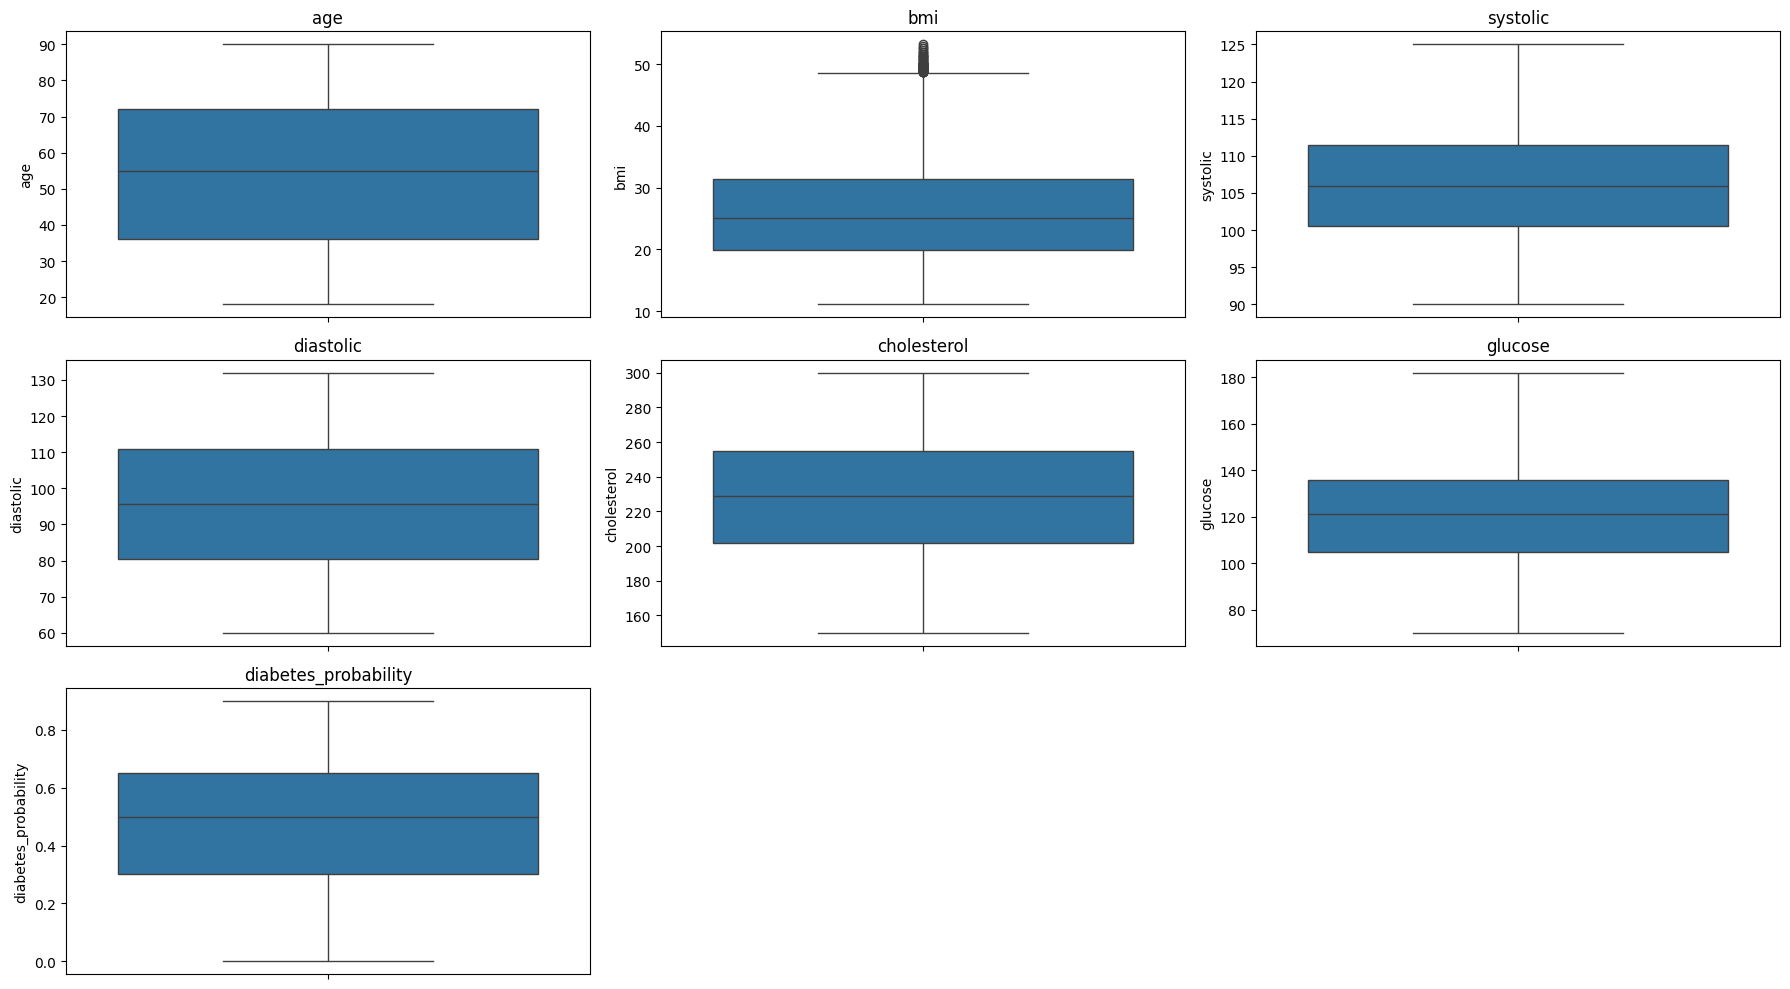

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(18,10))

for i,col in enumerate(num_cols):
    plt.subplot((len(num_cols)+2)//3,3,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

# Insights

*   The dataset is clean and complete with no missing values or duplicate records.


*  BMI contains a few clinically valid high values that were retained.

*   All variables have appropriate data types and consistent
categorical values.


*   The dataset is ready for exploratory analysis and predictive modeling.






# EDA

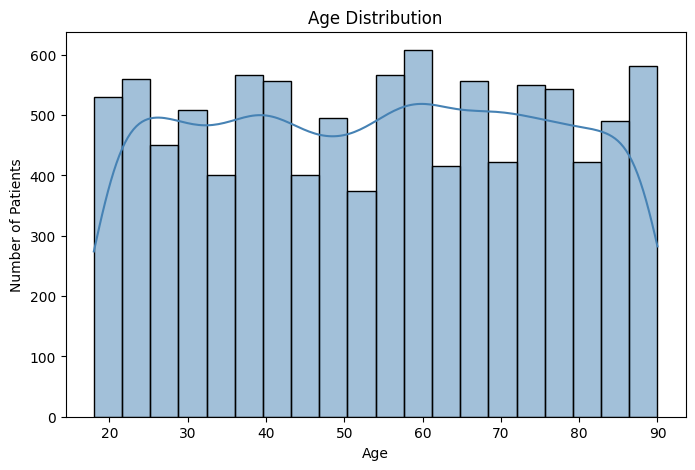

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='steelblue')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of Patients')
plt.show()

In [ ]:
fig = px.pie( df,names='gender',title='Gender Distribution',hole=0.4)

fig.show()

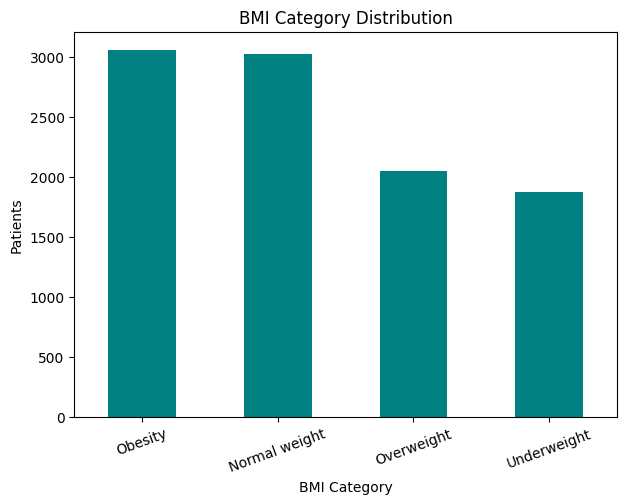

In [ ]:
plt.figure(figsize=(7,5))

df['bmi_category'].value_counts().plot(
    kind='bar',
    color='teal'
)

plt.title("BMI Category Distribution")
plt.xlabel("BMI Category")
plt.ylabel("Patients")
plt.xticks(rotation=20)

plt.show()

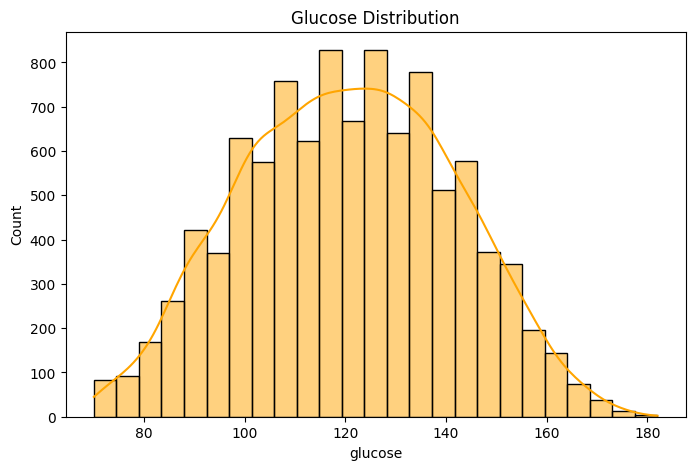

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['glucose'], bins=25, kde=True, color='orange')

plt.title("Glucose Distribution")

plt.show()

In [ ]:
fig = px.bar(
    df['cholesterol_category'].value_counts().reset_index(),
    x='cholesterol_category',
    y='count',
    title='Cholesterol Categories'
)

fig.show()

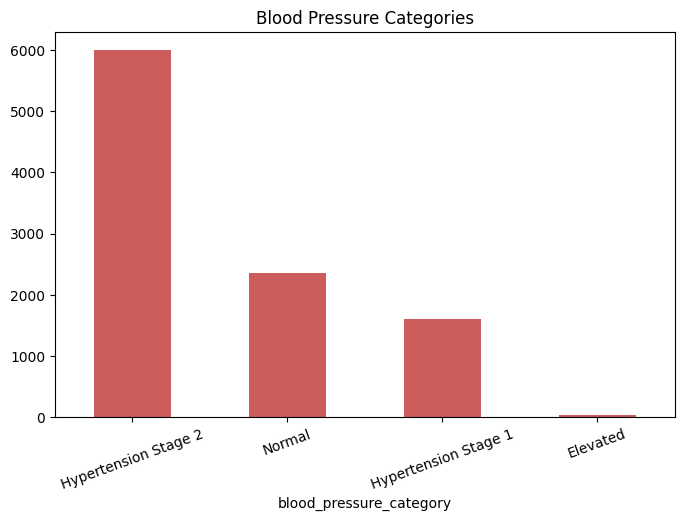

In [ ]:
plt.figure(figsize=(8,5))

df['blood_pressure_category'].value_counts().plot(
    kind='bar',
    color='indianred'
)

plt.title("Blood Pressure Categories")
plt.xticks(rotation=20)

plt.show()

In [ ]:
df['age_group'] = pd.cut(
    df['age'],
    bins=[18,30,40,50,60,70,80,90],
    labels=['18-30','31-40','41-50','51-60','61-70','71-80','81-90']
)

age_risk = (
    df.groupby('age_group', observed=False)['diabetes_probability']
      .mean()
      .reset_index()
)

fig = px.bar(
    age_risk,
    x='age_group',
    y='diabetes_probability',
    text_auto='.2f',
    color='diabetes_probability',
    title='Average Diabetes Probability by Age Group'
)

fig.update_layout(
    xaxis_title='Age Group',
    yaxis_title='Average Diabetes Probability'
)

fig.show()

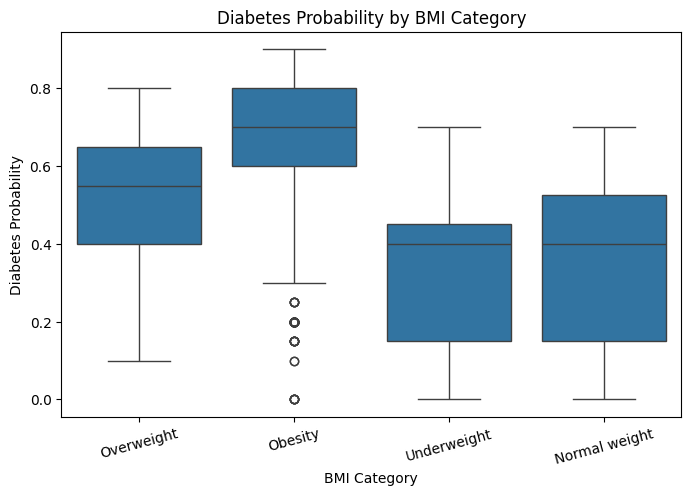

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='bmi_category',
    y='diabetes_probability'
)

plt.title('Diabetes Probability by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Diabetes Probability')
plt.xticks(rotation=15)

plt.show()

In [ ]:
bp = (
    df.groupby('blood_pressure_category', observed=False)['diabetes_probability']
      .mean()
      .reset_index()
)

fig = px.bar(
    bp,
    x='blood_pressure_category',
    y='diabetes_probability',
    color='diabetes_probability',
    text_auto='.2f',
    title='Average Diabetes Probability by Blood Pressure Category'
)

fig.update_layout(
    xaxis_title='Blood Pressure Category',
    yaxis_title='Average Diabetes Probability'
)

fig.show()

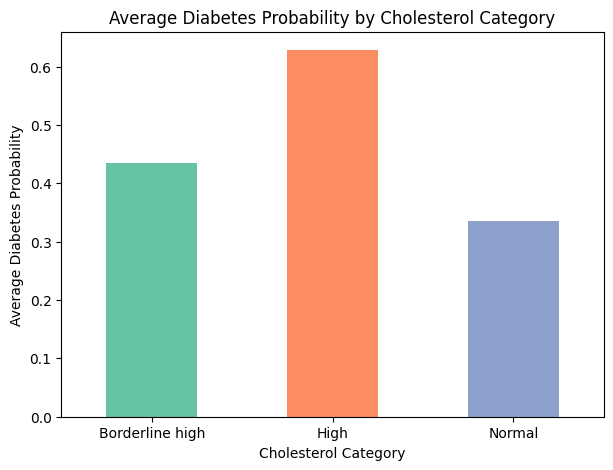

In [ ]:
chol = (
    df.groupby('cholesterol_category', observed=False)['diabetes_probability']
      .mean()
)

plt.figure(figsize=(7,5))

chol.plot(
    kind='bar',
    color=['#66c2a5','#fc8d62','#8da0cb']
)

plt.title('Average Diabetes Probability by Cholesterol Category')
plt.xlabel('Cholesterol Category')
plt.ylabel('Average Diabetes Probability')
plt.xticks(rotation=0)

plt.show()

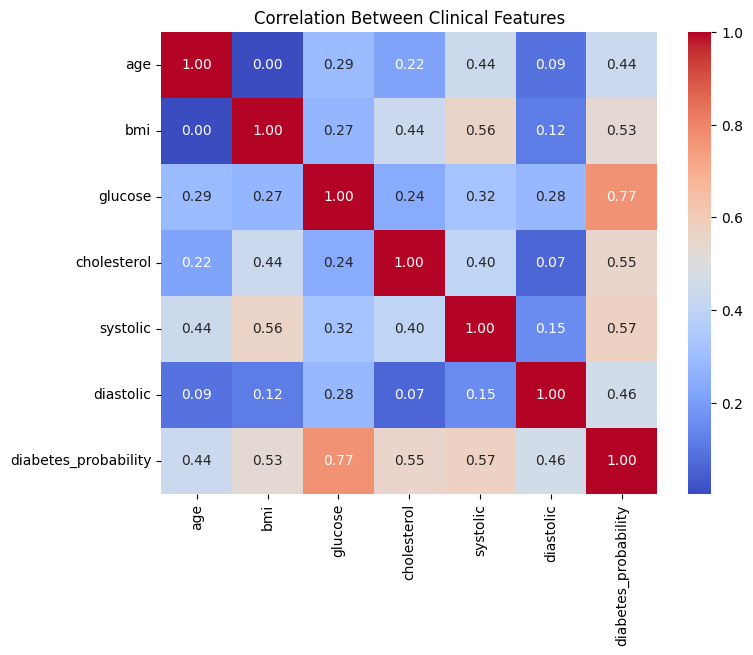

In [ ]:
corr = df[['age','bmi','glucose','cholesterol','systolic','diastolic','diabetes_probability']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Between Clinical Features')

plt.show()

# EDA Summary


*   The dataset contains a balanced distribution of adult patients across different age groups and genders.

*   Diabetes probability generally increases with age.

*   Patients with higher BMI categories tend to have higher diabetes probability.

*  Hypertension is associated with increased diabetes risk.
*  Higher cholesterol levels are linked to a greater average diabetes probability.


*  Glucose, BMI, age, and cholesterol show positive correlations with diabetes probability, making them important features for predictive modeling.


*  These findings support the selection of clinical features for the upcoming Machine Learning models.






# Feature Engineering

In [ ]:
def risk_level(prob):
    if prob < 0.4:
        return "Low Risk"
    elif prob < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

df["Risk_Level"] = df["diabetes_probability"].apply(risk_level)

In [ ]:
df.head()

,age,gender,bmi,bmi_category,systolic,diastolic,blood_pressure_category,cholesterol,cholesterol_category,glucose,diabetes_probability,age_group,Risk_Level
0,55,Female,29.59,Overweight,112.0,89.5,Hypertension Stage 1,247,High,139,0.65,51-60,Medium Risk
1,34,Male,30.68,Obesity,106.0,115.0,Hypertension Stage 2,255,High,101,0.60,31-40,Medium Risk
2,26,Male,15.96,Underweight,96.0,97.0,Hypertension Stage 2,234,Borderline high,97,0.15,18-30,Low Risk
3,63,Male,15.61,Underweight,109.6,115.3,Hypertension Stage 2,261,High,143,0.70,61-70,High Risk
4,37,Male,41.54,Obesity,110.0,103.0,Hypertension Stage 2,226,Borderline high,115,0.50,31-40,Medium Risk


In [ ]:
df["Risk_Level"].value_counts()

,count
Risk_Level,
Medium Risk,4705
Low Risk,3038
High Risk,2257


In [ ]:
round(df["Risk_Level"].value_counts(normalize=True) * 100, 2)

,proportion
Risk_Level,
Medium Risk,47.05
Low Risk,30.38
High Risk,22.57


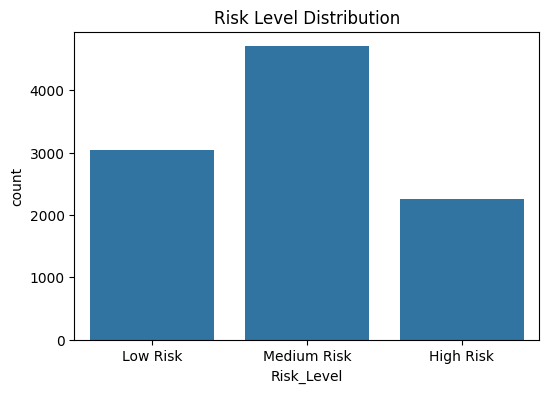

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Risk_Level",
    order=["Low Risk","Medium Risk","High Risk"]
)

plt.title("Risk Level Distribution")

plt.show()

In [ ]:
df.to_csv("MediAssist_Cleaned_Data.csv", index=False)

In [ ]:
df.drop(columns="diabetes_probability", inplace=True)


I drop diabetes_probability becuase The Risk_Level target was derived from diabetes_probability.
Keeping both would introduce data leakage and lead to misleading model performance.

In [ ]:
X = df.drop("Risk_Level", axis=1)

y = df["Risk_Level"]

In [ ]:
categorical_features = X.select_dtypes(include="object").columns.tolist()

numerical_features = X.select_dtypes(include=["int64","float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print()

print("Numerical Features:")
print(numerical_features)

Categorical Features:
['gender', 'bmi_category', 'blood_pressure_category', 'cholesterol_category']

Numerical Features:
['age', 'bmi', 'systolic', 'diastolic', 'cholesterol', 'glucose']


In [ ]:
y_encoded = y.map({
    "Low Risk": 0,
    "Medium Risk": 1,
    "High Risk": 2
})

In [ ]:
print(y_encoded.head())

0    1
1    1
2    0
3    2
4    1
Name: Risk_Level, dtype: int64


In [ ]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "gender",
        "bmi_category",
        "blood_pressure_category",
        "cholesterol_category"
    ],
    drop_first=True,
    dtype=int
)

In [ ]:
X_encoded.head()

,age,bmi,systolic,diastolic,cholesterol,glucose,age_group,gender_Male,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,blood_pressure_category_Hypertension Stage 1,blood_pressure_category_Hypertension Stage 2,blood_pressure_category_Normal,cholesterol_category_High,cholesterol_category_Normal
0,55,29.59,112.0,89.5,247,139,51-60,0,0,1,0,1,0,0,1,0
1,34,30.68,106.0,115.0,255,101,31-40,1,1,0,0,0,1,0,1,0
2,26,15.96,96.0,97.0,234,97,18-30,1,0,0,1,0,1,0,0,0
3,63,15.61,109.6,115.3,261,143,61-70,1,0,0,1,0,1,0,1,0
4,37,41.54,110.0,103.0,226,115,31-40,1,1,0,0,0,1,0,0,0


In [ ]:
print(X_encoded.shape)
print(y_encoded.shape)
print(X_encoded.dtypes)

(10000, 16)
(10000,)
age                                                int64
bmi                                              float64
systolic                                         float64
diastolic                                        float64
cholesterol                                        int64
glucose                                            int64
age_group                                       category
gender_Male                                        int64
bmi_category_Obesity                               int64
bmi_category_Overweight                            int64
bmi_category_Underweight                           int64
blood_pressure_category_Hypertension Stage 1       int64
blood_pressure_category_Hypertension Stage 2       int64
blood_pressure_category_Normal                     int64
cholesterol_category_High                          int64
cholesterol_category_Normal                        int64
dtype: object


### Final Dataset Preparation

The dataset was cleaned, analyzed, and transformed into a machine learning-ready format.

- Categorical features were encoded using One-Hot Encoding.
- The target variable Risk_Level was transformed into numerical classes:
  - 0: Low Risk
  - 1: Medium Risk
  - 2: High Risk

Final dataset:
- Features: 16
- Target: Risk_Level

In [ ]:
X_encoded = X_encoded.drop(columns=["age_group"])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(8000, 15)
(2000, 15)


In [ ]:
print(X_train.select_dtypes(include="object").columns)

Index([], dtype='object')


In [ ]:
print(X_train.dtypes)


age                                               int64
bmi                                             float64
systolic                                        float64
diastolic                                       float64
cholesterol                                       int64
glucose                                           int64
gender_Male                                       int64
bmi_category_Obesity                              int64
bmi_category_Overweight                           int64
bmi_category_Underweight                          int64
blood_pressure_category_Hypertension Stage 1      int64
blood_pressure_category_Hypertension Stage 2      int64
blood_pressure_category_Normal                    int64
cholesterol_category_High                         int64
cholesterol_category_Normal                       int64
dtype: object


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_prob = lr.predict_proba(X_test_scaled)

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

def evaluate_model(name, y_true, y_pred, y_prob):

    print("=" * 50)
    print(name)
    print("=" * 50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, average="weighted"))
    print("Recall   :", recall_score(y_true, y_pred, average="weighted"))
    print("F1 Score :", f1_score(y_true, y_pred, average="weighted"))

    auc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr"
    )

    print("ROC AUC  :", auc)

    print("\nClassification Report")
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Logistic Regression
Accuracy : 0.9005
Precision: 0.9011741750011631
Recall   : 0.9005
F1 Score : 0.9005059124247771
ROC AUC  : 0.98221017578192

Classification Report
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       608
           1       0.88      0.91      0.90       941
           2       0.91      0.86      0.88       451

    accuracy                           0.90      2000
   macro avg       0.91      0.89      0.90      2000
weighted avg       0.90      0.90      0.90      2000



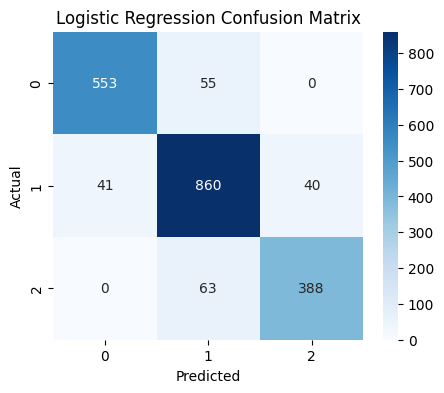

Random Forest
Accuracy : 0.999
Precision: 0.9990021208907741
Recall   : 0.999
F1 Score : 0.9989997070623338
ROC AUC  : 0.9999878257595372

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       608
           1       1.00      1.00      1.00       941
           2       1.00      1.00      1.00       451

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



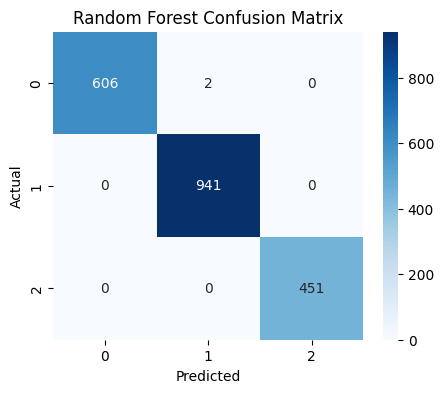

XGBoost
Accuracy : 0.9995
Precision: 0.9995005307855627
Recall   : 0.9995
F1 Score : 0.9994999270055446
ROC AUC  : 0.9999992716476723

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       608
           1       1.00      1.00      1.00       941
           2       1.00      1.00      1.00       451

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



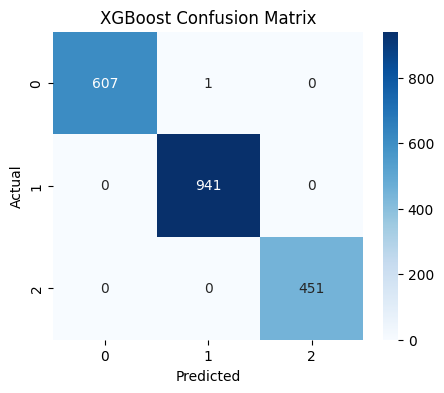

In [ ]:
evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred,
    lr_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)

evaluate_model(
    "XGBoost",
    y_test,
    xgb_pred,
    xgb_prob
)

In [ ]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],

    "Precision":[
        precision_score(y_test, lr_pred, average="weighted"),
        precision_score(y_test, rf_pred, average="weighted"),
        precision_score(y_test, xgb_pred, average="weighted")
    ],

    "Recall":[
        recall_score(y_test, lr_pred, average="weighted"),
        recall_score(y_test, rf_pred, average="weighted"),
        recall_score(y_test, xgb_pred, average="weighted")
    ],

    "F1 Score":[
        f1_score(y_test, lr_pred, average="weighted"),
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9005,0.901174,0.9005,0.900506
1,Random Forest,0.9990,0.999002,0.9990,0.999000
2,XGBoost,0.9995,0.999501,0.9995,0.999500


In [ ]:
print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.999


In [ ]:
print("Train Accuracy:", xgb.score(X_train, y_train))
print("Test Accuracy:", xgb.score(X_test, y_test))

Train Accuracy: 1.0
Test Accuracy: 0.9995


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X_encoded,
    y_encoded,
    cv=5,
    scoring="accuracy"
)

print(scores)
print("Mean Accuracy:", scores.mean())

[0.998  0.997  0.9985 0.9995 0.998 ]
Mean Accuracy: 0.9982000000000001


In [ ]:
import joblib

joblib.dump(xgb, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
5,glucose,0.313462
4,cholesterol,0.164655
0,age,0.141652
1,bmi,0.137669
3,diastolic,0.134585
2,systolic,0.075757
8,bmi_category_Overweight,0.025383
6,gender_Male,0.003707
7,bmi_category_Obesity,0.001529
10,blood_pressure_category_Hypertension Stage 1,0.000906


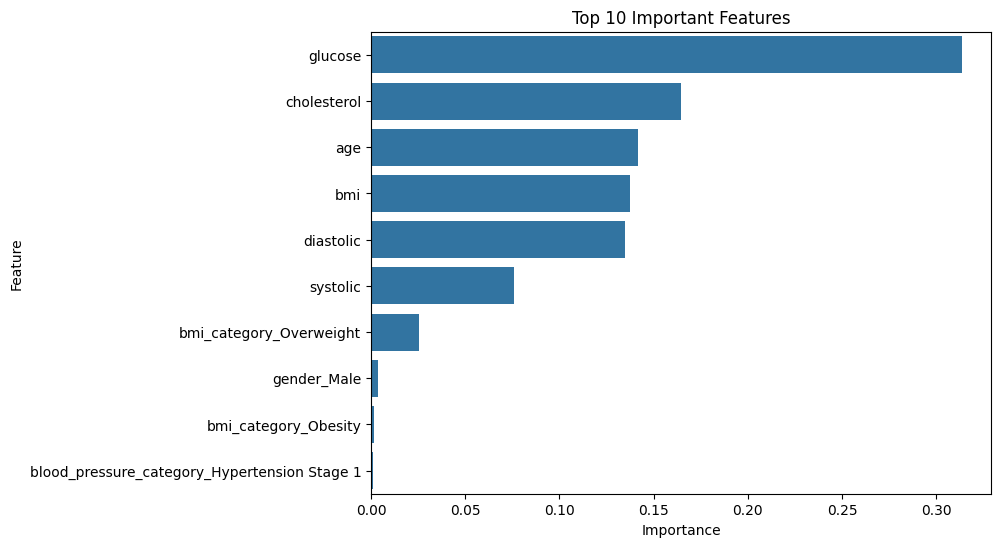

In [ ]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

In [ ]:
results_df = pd.DataFrame({
    "Actual": y_test,
    "Prediction": xgb_pred
})

results_df["Probability"] = xgb_prob.max(axis=1)

In [ ]:
results_df.to_csv(
    "prediction_results.csv",
    index=False
)

In [ ]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Clinical Decision Support & Patient Prediction

In [ ]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import os
from datetime import datetime
from difflib import SequenceMatcher
import smtplib
from email.mime.multipart import MIMEMultipart
from email.mime.text import MIMEText
from email.header import Header

def send_patient_data_to_hospital(patient_id, age, gender, bmi, bmi_category,
                                 sys_bp, dia_bp, bp_category,
                                 cholesterol, chol_category, glucose, prediction_result=None):

    sender_email = "marimkhaled2006@gmail.com"
    app_password = "ijbxxgiotesofhqp"
    receiver_email = "tasneem200752@gmail.com"

    msg = MIMEMultipart()
    msg['From'] = sender_email
    msg['To'] = receiver_email
    msg['Subject'] = Header(f" New patient data- Patient ID: {patient_id}", 'utf-8')
    body_text = f"""
    Welcome,

    new patient's data was entered into the system:

    Patient health data 📋:

       Patient ID: {patient_id}
       Age: {age}
       Gender: {gender}
       BMI: {bmi} ({bmi_category})
       Blood Pressure: {sys_bp}/{dia_bp} mmHg ({bp_category})
       Cholesterol: {cholesterol} mg/dL ({chol_category})
       Glucose: {glucose} mg/dL
    """
    if prediction_result is not None:
        body_text += f"\n Prediction Result: {prediction_result}\n"

    body_text += "\n Welcome, \n Medical Reporting System"
    msg.attach(MIMEText(body_text, 'plain', 'utf-8'))


    try:
        server = smtplib.SMTP('smtp.gmail.com', 587)
        server.starttls()
        server.login(sender_email, app_password)
        server.sendmail(sender_email, receiver_email, msg.as_bytes())
        server.quit()
        st.toast(f"✉️ تم إرسال البيانات للإيميل بنجاح! (ID: {patient_id})", icon="✅")
        return True
    except Exception as e:
        st.error(f"❌ حدث خطأ أثناء الإرسال: {e}")
        return False


st.set_page_config(
    page_title="MediAssist AI",
    page_icon="🏥",
    layout="wide"
)


model = joblib.load("best_model.pkl")


def get_recommendations(age, bmi, glucose, cholesterol, systolic, diastolic, risk_level):
    recommendations = []

    if bmi >= 30:
        recommendations.append("Nutrition Consultation is recommended due to high BMI.")

    if glucose >= 126:
        recommendations.append("HbA1c test is recommended to assess long-term blood glucose control.")

    if systolic >= 140:
        recommendations.append("Regular blood pressure monitoring is recommended.")

    if cholesterol >= 240:
        recommendations.append("Lipid profile review and lifestyle modification are recommended.")

    if age >= 60:
        recommendations.append("Regular diabetes screening and routine clinical follow-up are recommended.")

    if risk_level == "High Risk":
        recommendations.append("Immediate medical follow-up is strongly recommended.")

    if not recommendations:
        recommendations.append("Maintain a healthy lifestyle and attend regular medical check-ups.")

    return recommendations


def prepare_patient_data(age, gender, bmi, bmi_category, systolic, diastolic,
                         blood_pressure_category, cholesterol, cholesterol_category, glucose):


    patient_dict = {
        'age': float(age),
        'bmi': float(bmi),
        'systolic': float(systolic),
        'diastolic': float(diastolic),
        'cholesterol': float(cholesterol),
        'glucose': float(glucose),
        'gender_Male': 1 if gender == "Male" else 0,
        'bmi_category_Obesity': 1 if bmi_category == "Obesity" else 0,
        'bmi_category_Overweight': 1 if bmi_category == "Overweight" else 0,
        'bmi_category_Underweight': 1 if bmi_category == "Underweight" else 0,
        'blood_pressure_category_Hypertension Stage 1': 1 if blood_pressure_category == "Hypertension Stage 1" else 0,
        'blood_pressure_category_Hypertension Stage 2': 1 if blood_pressure_category == "Hypertension Stage 2" else 0,
        'blood_pressure_category_Normal': 1 if blood_pressure_category == "Normal" else 0,
        'cholesterol_category_High': 1 if cholesterol_category == "High" else 0,
        'cholesterol_category_Normal': 1 if cholesterol_category == "Normal" else 0
    }

    patient_df = pd.DataFrame([patient_dict])


    if hasattr(model, "feature_names_in_"):
        expected_cols = [str(col) for col in model.feature_names_in_]
        patient_df = patient_df[expected_cols]

    return patient_df


def predict_patient(age, gender, bmi, bmi_category, systolic, diastolic,
                    blood_pressure_category, cholesterol, cholesterol_category, glucose):

    patient_df = prepare_patient_data(
        age, gender, bmi, bmi_category, systolic, diastolic,
        blood_pressure_category, cholesterol, cholesterol_category, glucose
    )

    pred_raw = int(model.predict(patient_df)[0])
    probabilities = model.predict_proba(patient_df)[0]


    risk_labels = {
        0: "Low Risk",
        1: "Medium Risk",
        2: "High Risk"
    }

    risk = risk_labels.get(pred_raw, "Low Risk")
    confidence = round(float(probabilities[pred_raw]) * 100, 2)

    recommendations = get_recommendations(
        age, bmi, glucose, cholesterol, systolic, diastolic, risk
    )

    return {
        "Risk Level": risk,
        "Probability": confidence,
        "Recommendations": recommendations
    }

intents = {

    "Greeting": {
        "patterns": [
            "hi","hello","hey","good morning","good evening"
        ],
        "response":
        "Hello 👋 I'm MediAssist AI. How can I help you today?"
    },

    "BMI": {
        "patterns":[
            "bmi",
            "what is bmi",
            "body mass index",
            "explain bmi",
            "define bmi"
        ],
        "response":
        "BMI (Body Mass Index) estimates body fat using your height and weight."
    },

    "Glucose": {
        "patterns":[
            "glucose",
            "blood sugar",
            "high glucose",
            "what is glucose",
            "glucose level"
        ],
        "response":
        "Glucose is the amount of sugar in the blood. High glucose levels may increase diabetes risk."
    },

    "Blood Pressure": {
        "patterns":[
            "blood pressure",
            "hypertension",
            "high blood pressure"
        ],
        "response":
        "Blood pressure is the force of blood against artery walls. Maintaining a healthy blood pressure is very important."
    },

    "Cholesterol": {
        "patterns":[
            "cholesterol",
            "high cholesterol",
            "ldl",
            "hdl"
        ],
        "response":
        "High cholesterol increases cardiovascular disease risk. Healthy eating and exercise can help."
    },

    "Exercise": {
        "patterns":[
            "exercise",
            "gym",
            "walking",
            "running",
            "physical activity"
        ],
        "response":
        "Regular exercise improves insulin sensitivity and helps reduce diabetes risk."
    },

    "Diet": {
        "patterns":[
            "diet",
            "food",
            "healthy food",
            "nutrition",
            "eat"
        ],
        "response":
        "Eat more vegetables, fruits, whole grains and lean protein while reducing sugary foods."
    },

    "Symptoms": {
        "patterns":[
            "symptoms",
            "diabetes symptoms",
            "signs"
        ],
        "response":
        "Common diabetes symptoms include excessive thirst, frequent urination, fatigue and blurred vision."
    },

    "Thanks": {
        "patterns":[
            "thanks",
            "thank you"
        ],
        "response":
        "You're welcome 😊"
    }

}

def chatbot_response(question, risk):

    question = question.lower()



    prediction_keywords = [
        "risk",
        "prediction",
        "result",
        "healthy",
        "condition",
        "diagnosis"
    ]

    if any(word in question for word in prediction_keywords):

        if risk == "Low Risk":

            return """
🟢 Low Risk

Great news! 🎉

Based on your health information, you are currently considered Low Risk for diabetes.

This means your health indicators are generally within a healthy range.

✅ Continue maintaining a healthy lifestyle.
🥗 Eat healthy food.
🏃 Exercise regularly.
💧 Drink enough water.
🩺 Keep attending routine medical check-ups.

Keep up the good work!
"""

        elif risk == "Medium Risk":

            return """
🟡 Medium Risk

Your health condition is generally good, but there are some factors that need attention.

You are not in immediate danger, but you should start taking better care of your health.

✅ Follow a healthy diet.
🏃 Exercise regularly.
🩸 Monitor your blood glucose.
🧪 Perform routine laboratory tests.
👨‍⚕️ Visit your doctor regularly for follow-up.

Healthy lifestyle changes can significantly reduce your future diabetes risk.
"""

        else:

            return """
🔴 High Risk

Your assessment indicates a High Risk of diabetes.

⚠ Please visit a hospital or healthcare professional as soon as possible.

The doctor may recommend:

🩸 Blood glucose tests.
🧪 HbA1c test.
📋 Complete medical evaluation.

Early diagnosis and treatment can help prevent serious complications.
"""



    best_score = 0
    best_answer = None

    for intent in intents.values():

        for pattern in intent["patterns"]:

            score = SequenceMatcher(None, question, pattern).ratio()

            if score > best_score:

                best_score = score
                best_answer = intent["response"]

    if best_score >= 0.45:

        return best_answer

    return (
        "I'm MediAssist AI 🤖.\n"
        "I can answer questions about diabetes, BMI, glucose, cholesterol, blood pressure, healthy lifestyle and your prediction."
    )


st.title("🏥 MediAssist AI")
st.subheader("Clinical Decision Support System")

st.markdown("---")
st.header("Patient Information")

patient_id = st.number_input("Patient ID", min_value=1, step=1)
age = st.number_input("Age", min_value=18, max_value=100, value=30)
gender = st.selectbox("Gender", ["Male", "Female"])
bmi = st.number_input("BMI", min_value=10.0, max_value=60.0, value=25.0)
bmi_category = st.selectbox("BMI Category", ["Normal", "Overweight", "Obesity", "Underweight"])
systolic = st.number_input("Systolic Blood Pressure", min_value=70, max_value=250, value=120)
diastolic = st.number_input("Diastolic Blood Pressure", min_value=40, max_value=150, value=80)
blood_pressure_category = st.selectbox("Blood Pressure Category", ["Normal", "Hypertension Stage 1", "Hypertension Stage 2"])
cholesterol = st.number_input("Cholesterol", min_value=50, max_value=400, value=180)
cholesterol_category = st.selectbox("Cholesterol Category", ["Normal", "High"])
glucose = st.number_input("Glucose", min_value=50, max_value=400, value=100)

st.markdown("---")

predict_button = st.button("Predict")

if predict_button:
    result = predict_patient(
        age=age,
        gender=gender,
        bmi=bmi,
        bmi_category=bmi_category,
        systolic=systolic,
        diastolic=diastolic,
        blood_pressure_category=blood_pressure_category,
        cholesterol=cholesterol,
        cholesterol_category=cholesterol_category,
        glucose=glucose
    )

    st.session_state["result"] = result

    st.success("Prediction Completed Successfully")
    st.subheader("Patient Result")
    st.write("Patient ID:", patient_id)

    if result["Risk Level"] == "Low Risk":
        st.success(f"Risk Level: {result['Risk Level']}")
    elif result["Risk Level"] == "Medium Risk":
        st.warning(f"Risk Level: {result['Risk Level']}")
    else:
        st.error(f"Risk Level: {result['Risk Level']}")

    st.write(f"**Prediction Probability:** {result['Probability']}%")


    new_patient = pd.DataFrame([{
        "Patient ID": patient_id,
        "Age": age,
        "Gender": gender,
        "BMI": bmi,
        "BMI Category": bmi_category,
        "Systolic": systolic,
        "Diastolic": diastolic,
        "Blood Pressure Category": blood_pressure_category,
        "Cholesterol": cholesterol,
        "Cholesterol Category": cholesterol_category,
        "Glucose": glucose,
        "Risk Level": result["Risk Level"],
        "Probability": result["Probability"],
        "Prediction Date": datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    }])


    drive_folder = "/content/drive/MyDrive"
    file_name = os.path.join(drive_folder, "new_patients_updated.csv")


    if os.path.exists(file_name):
        old_data = pd.read_csv(file_name)
        new_patient = pd.concat([old_data, new_patient], ignore_index=True)


    new_patient.to_csv(file_name, index=False)

    send_patient_data_to_hospital(
        patient_id=patient_id,
        age=age,
        gender=gender,
        bmi=bmi,
        bmi_category=bmi_category,
        sys_bp=systolic,
        dia_bp=diastolic,
        bp_category=blood_pressure_category,
        cholesterol=cholesterol,
        chol_category=cholesterol_category,
        glucose=glucose,
        prediction_result=result["Risk Level"]
    )


    st.subheader("Clinical Recommendations")
    for rec in result["Recommendations"]:
        st.write("✅", rec)

    st.markdown("---")


st.subheader("💬 MediAssist AI Assistant")

st.write("Ask me anything about diabetes or your prediction.")

question = st.text_input(
    "Your Question",
    placeholder="Example: What is BMI?"
)

if st.button("Ask AI"):

    if "result" not in st.session_state:

        st.warning("⚠ Please click Predict first.")

    elif question.strip() == "":

        st.warning("⚠ Please enter your question.")

    else:

        answer = chatbot_response(
            question,
            st.session_state["result"]["Risk Level"]
        )

        st.success(answer)



Writing app.py


In [ ]:
!pip install -q streamlit
!npm install -g localtunnel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 64.6 MB/s eta 0:00:00
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇
added 22 packages in 2s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇

In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹⠸⠼⠴

⠦2026-07-31 21:28:58.630 Uvicorn server started on :::8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.186.6.183:8501

your url is: https://weak-mails-cheat.loca.lt
34.186.6.183


In [ ]:
!curl https://loca.lt/mytunnelpassword

^C
